In [1]:
import glob
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from lmfit import Model

Common function definitions go here

In [2]:
def sort_func(filename):
    file_parts = filename.split('_')
    try:
        return int(file_parts[-1].split('.')[0])
    except ValueError:
        return 0

def shrink_array(arr, factor):
    """Re-bin an array by an integer factor.
    In the new array, each bin is the sum of the original bins.
    """
    old_shape = arr.shape
    new_shape = (old_shape[0] // factor, old_shape[1] // factor)
    new_arr = np.zeros(new_shape)
    for i in range(new_shape[0]):
        for j in range(new_shape[1]):
            new_arr[i, j] = np.sum(arr[i*factor:(i+1)*factor, j*factor:(j+1)*factor])
    return new_arr

def shrink_array_roll(arr, factor: int, offset_0: int = 0, offset_1: int = 0):
    """Offset the array by a given amount and then re-bin it with integer factor.
    """
    offset_0 = offset_0 % factor
    offset_1 = offset_1 % factor
    rolled_array = np.roll(arr, (offset_0, offset_1), axis=(0, 1))
    return shrink_array(rolled_array, factor)

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## Parameter Definitions

In [3]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_04_07/afc_longterm/2D')
bin_size = 0.5  # unit: ns
storage_time = 1000  # unit: ns
files_to_include = 16

# data processing params
signal_idler_offset_guess = 454
idler_lim_input = (300, 1300)

Intermediate plotting definitions (primarily colormap)

In [4]:
cmap_name = 'magma'
cmap = plt.get_cmap(cmap_name)
new_cmap = truncate_colormap(cmap, minval=0.1, maxval=1.0)

In [5]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (4, 3)  # inches
dpi = 300

# colors
color_source = '#7570b3'
color_memory = '#d95f02'

# figure layout
vertical_ratios = (1, 1)  # for two plots
horizontal_ratios = (4, 2)
vertical_padding = 0.02
horizontal_padding = 0.02

## Load Data

In [6]:
all_files = glob.glob(os.path.join(DATA_DIR, '*.npz'))
all_files.sort(key=sort_func)

# load data
all_counts = []
all_bins = []
all_freqs = []
file_numbers = []
for file in all_files:
    try:
        file_number = int(file.split('/')[-1].split('.')[0].split('_')[-1])
    except ValueError:
        file_number = 0
    file_numbers.append(file_number)

    data = np.load(file)
    counts = data['counts']
    bins = data['bins']
    freqs_start = data['freq_start']
    freqs_end = data['freq_end']
    all_counts.append(counts)
    all_bins.append(bins)
    all_freqs.append((freqs_start, freqs_end))

In [7]:
all_hist = np.sum(all_counts[:files_to_include], axis=0)

## Recovery of Bidirectional Histograms using Diagonal Sums

These cells also identify the primary candidate diagonal for echo analysis

In [8]:
# compute diagonals
start_diag = 0
end_diag = all_hist.shape[0] - idler_lim_input[1]
offsets = np.arange(start_diag, end_diag, 1)
offsets = offsets * -1
diags = [np.diagonal(all_hist, offset=offset)[idler_lim_input[0]:idler_lim_input[1]]
         for offset in offsets]
diag_sum = np.sum(diags, axis=1)

# convert from offset to signal-idler arrival time in ns
# bin size for experiment is 500 ps
time_arr = offsets * -bin_size

# get input and echo counts coincidence histogram
# echo is shifted by 1 us to coincide temporally with input
input_idx = np.where(np.logical_and(time_arr > (signal_idler_offset_guess*0.5)-25,
                                    time_arr < (signal_idler_offset_guess*0.5)+25))[0]
echo_idx = input_idx + int(storage_time / bin_size)

input_center = time_arr[np.argmax(diag_sum)]

echo_center = 2456  # guessing this value based on the echo histogram, confirmed based on maximum CAR for later cells

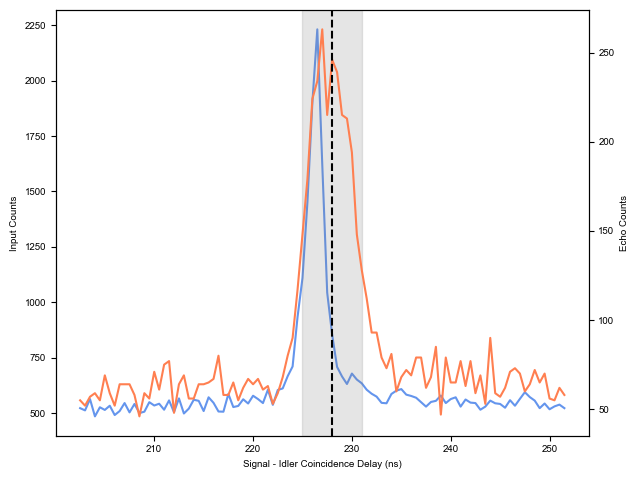

In [9]:
# plot diagonals and zoom on certain regions
fig, ax = plt.subplots()
ax_r = ax.twinx()
ax.plot(time_arr[input_idx], diag_sum[input_idx],
        color='cornflowerblue')
ax_r.plot(time_arr[input_idx], diag_sum[echo_idx],
          color='coral')
ax_r.axvline(time_arr[echo_center]-1e3,
             color='k', ls='--')
ax_r.axvspan(time_arr[echo_center]-1e3 - 3, time_arr[echo_center]-1e3 + 3,
             color='gray', alpha=0.2)
ax.set_ylabel('Input Counts')
ax_r.set_ylabel('Echo Counts')
ax.set_xlabel('Signal - Idler Coincidence Delay (ns)')
fig.tight_layout()

## Square Rebinning

Here, we rebin the histogram with square bins, such that the center of the coincidence peak lies diagonally across one square bin.

First, do the rebinning

In [10]:
rebin_factors = np.arange(4, 41, 1)  # unit: no. of bins
rebinned_hists = []

for factor in rebin_factors:
    offset_0 = -echo_center
    rebinned_array = shrink_array_roll(all_hist, factor=factor, offset_0=offset_0)
    rebinned_hists.append(rebinned_array)

Next, we plot the diagonal for each to extract $g^{(2)}$ and error rate

In [11]:
all_diagonal_sums = []
for factor, hist in zip(rebin_factors, rebinned_hists):
    end_diag = hist.shape[0] - (idler_lim_input[1] // factor)
    offsets = np.arange(0, end_diag, 1)
    offsets = offsets * -1
    diags = [np.diagonal(hist, offset=offset)[idler_lim_input[0]//factor:idler_lim_input[1]//factor]
             for offset in offsets]
    diag_sum = np.sum(diags, axis=1)
    all_diagonal_sums.append(diag_sum)

In [12]:
contrast_vals = []
contrast_err = []
center_idxs = []
width = 200  # unit: ns

for factor, diagonal in zip(rebin_factors, all_diagonal_sums):
    bin_size_time = factor * bin_size
    time_center = echo_center * bin_size
    time_bins = np.arange(len(diagonal)) * bin_size_time
    idx_to_analyze = np.where(np.logical_and(time_bins >= time_center - width/2, time_bins <= time_center + width/2))[0]
    counts_to_analyze = diagonal[idx_to_analyze]
    center_idx = np.argmax(counts_to_analyze)
    center_idxs.append(center_idx)
    center_counts = np.max(counts_to_analyze)
    bg_left_counts = counts_to_analyze[center_idx - 1]
    bg_right_counts = counts_to_analyze[center_idx + 1]
    bg_counts = (bg_left_counts + bg_right_counts) / 2

    contrast = center_counts / bg_counts
    contrast_vals.append(contrast)

    center_err = np.sqrt(center_counts)
    bg_err = np.sqrt(bg_left_counts + bg_right_counts) / 2
    contrast_err.append(contrast * np.sqrt((center_err / center_counts) ** 2 + (bg_err / bg_counts) ** 2))

Text(0, 0.5, 'Center Bin Contrast')

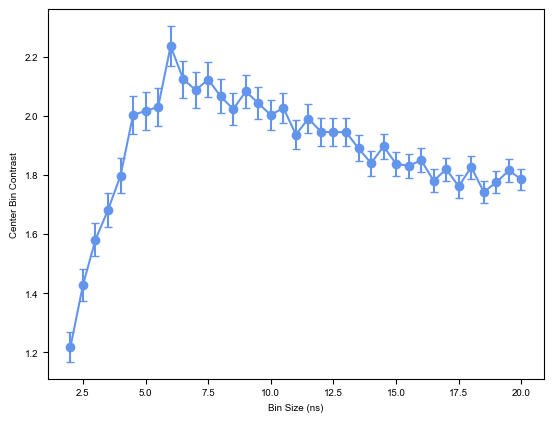

In [37]:
plt.errorbar(np.array(rebin_factors) * bin_size, contrast_vals, yerr=contrast_err,
             marker='o', capsize=3, color='cornflowerblue')
plt.xlabel('Bin Size (ns)')
plt.ylabel('Center Bin Contrast')

In [38]:
contrast_vals = np.array(contrast_vals)
contrast_error = 1 / contrast_vals
error_yerr = (contrast_err / contrast_vals) * (1 / (contrast_vals))

Text(0, 0.5, 'Center Bin Estimated Error')

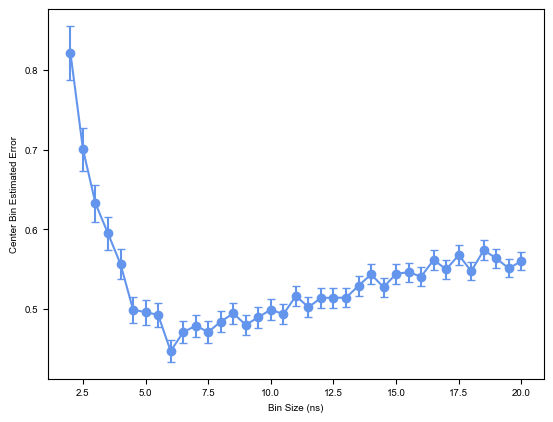

In [40]:
plt.errorbar(np.array(rebin_factors) * bin_size, contrast_error, yerr=error_yerr,
             marker='o', capsize=3, color='cornflowerblue')
plt.xlabel('Bin Size (ns)')
plt.ylabel('Center Bin Estimated Error')

In [41]:
idx_to_plot = np.argmax(contrast_vals)
factor = rebin_factors[idx_to_plot]
rebinned_array = rebinned_hists[idx_to_plot]

# plot summed histogram (zoom on echo)
signal_start = (idler_lim_input[0] + signal_idler_offset_guess + 2000) // factor + 1
signal_end = (idler_lim_input[1] + signal_idler_offset_guess + 2000) // factor + 1
idler_start = idler_lim_input[0] // factor
idler_end = idler_lim_input[1] // factor
echo_zoom = rebinned_array[signal_start:signal_end, idler_start:idler_end]

time_bins = np.arange(len(echo_zoom)) * factor * bin_size

# plot log scale
plt.imshow(echo_zoom, cmap=new_cmap,
           norm=colors.LogNorm(vmin=1, vmax=echo_zoom.max()))
plt.gca().set_facecolor('black')
plt.xlabel('Idler Bin')
plt.ylabel('Signal Bin')
plt.colorbar(label='Counts')
plt.title(f'Rebinned Array (Bin Size = {factor * bin_size} ns, Factor = {factor})')
plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'LogNorm'

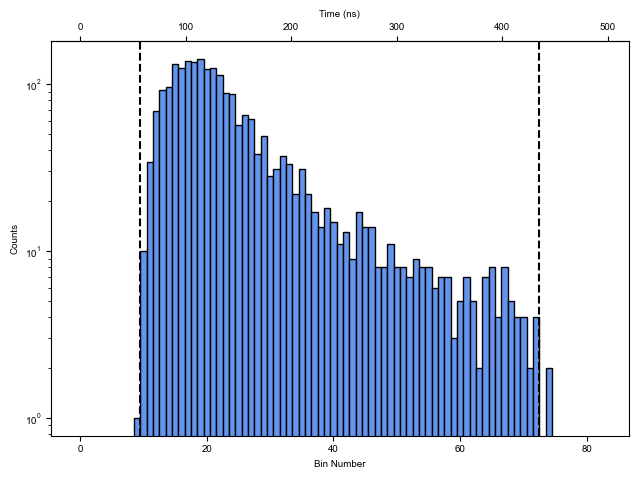

In [16]:
time_bin_diagonal = np.diagonal(echo_zoom)
time_bin_off_diagonal_right = np.diagonal(echo_zoom, offset=1)
time_bin_off_diagonal_left = np.diagonal(echo_zoom, offset=-1)
off_diagonal = (time_bin_off_diagonal_right + time_bin_off_diagonal_left) / 2
bin_numbers = np.arange(len(time_bin_diagonal))

# functions for axes
def bin_to_time(bin_number):
    return bin_number * factor * bin_size

def time_to_bin(time):
    return time / (factor * bin_size)

fig, ax = plt.subplots()
ax.bar(bin_numbers, time_bin_diagonal, width=1, color='cornflowerblue', edgecolor='k')
# ax.bar(bin_numbers[1:], off_diagonal, width=1, color='coral', edgecolor='k')
ax.set_xlabel('Bin Number')
ax.set_ylabel('Counts')
ax.set_yscale('log')
sec_ax = ax.secondary_xaxis('top', functions=(bin_to_time, time_to_bin))
sec_ax.set_xlabel('Time (ns)')

ax.axvline(10 - 0.5, color='k', ls='--')
ax.axvline(73 - 0.5, color='k', ls='--')

fig.tight_layout()

## Entropy Analysis

In [17]:
bin_nums = np.arange(10, 70, 1, dtype=int)
min_start_idx = 0
max_max_start_idx = len(time_bin_diagonal) - min(bin_nums)
entropies = np.empty((len(bin_nums), max_max_start_idx+1))
entropies[:] = np.nan
entropies_scaled = np.empty((len(bin_nums), max_max_start_idx+1))
entropies_scaled[:] = np.nan

for i, bin_num in enumerate(bin_nums):
    max_start_idx = len(time_bin_diagonal) - bin_num

    for j, start_idx in enumerate(range(min_start_idx, max_start_idx)):
        end_idx = start_idx + bin_num
        time_bins_to_analyze = time_bin_diagonal[start_idx:end_idx]
        counts_tot = np.sum(time_bins_to_analyze)
        amplitudes = time_bins_to_analyze / counts_tot
        entropy = 0
        for amplitude in amplitudes:
            if amplitude > 0:
                entropy -= amplitude * np.log2(amplitude)

        entropies[i, j] = entropy
        entropies_scaled[i, j] = entropy * counts_tot

In [18]:
max_total_entropy = np.nanmax(entropies_scaled, axis=1)
max_entropy_idx = np.nanargmax(entropies_scaled, axis=1)
max_entropy = np.array([entropies[i, max_entropy_idx[i]] for i in range(len(bin_nums))])

In [19]:
for frame_size, max_idx, entropy_per in zip(bin_nums, max_entropy_idx, max_entropy):
    print(frame_size, max_idx, entropy_per)

10 13 3.3090212420291145
11 13 3.442054710369876
12 13 3.5641327181645286
13 12 3.6702091153514624
14 12 3.76323633104883
15 12 3.8557689992227524
16 12 3.94196882676863
17 12 4.008568412313784
18 12 4.080838136523158
19 11 4.139425356200911
20 11 4.19076595460258
21 12 4.246052187394274
22 11 4.300016513568907
23 11 4.351744319149692
24 11 4.392181121396577
25 11 4.440071325134277
26 11 4.478878132677945
27 11 4.511575637226319
28 11 4.540120990628705
29 11 4.573117955469461
30 11 4.602192802289062
31 11 4.625695413059161
32 11 4.651681739491455
33 10 4.673314975364867
34 11 4.701988824397519
35 11 4.728404221134061
36 11 4.754533650623709
37 10 4.775308631172502
38 10 4.793018184225371
39 11 4.811951486464452
40 10 4.832284010545591
41 10 4.849628649748265
42 10 4.866865042113312
43 10 4.882478693032603
44 10 4.900934803960143
45 10 4.917853420187147
46 10 4.9346681770361345
47 10 4.948340054950614
48 10 4.963507216359911
49 10 4.97859314830434
50 10 4.986682771037319
51 10 4.9984697

## CAR Analysis

First, get echo pulse in frame size

In [20]:
start_idx = 10
frame_size = 63

end_idx = start_idx + frame_size

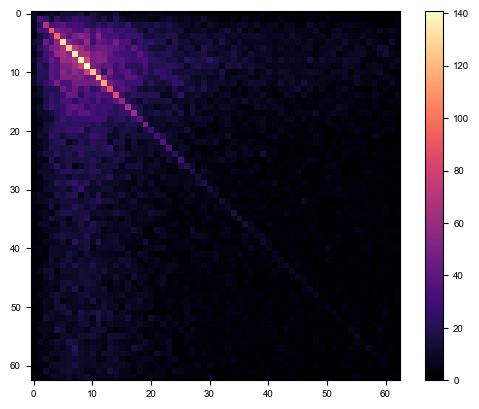

In [21]:
echo_center = echo_zoom[start_idx:end_idx, start_idx:end_idx]
plt.imshow(echo_center, cmap='magma')
plt.colorbar()

### Determine CAR for various portions of graph

Get subsets of pulse corresponding to high and low counts (first 100 ns, after first 100 ns)

In [22]:
all_high_sums = []
all_low_sums = []
all_high_counts = []
all_low_counts = []
all_high_car = []
all_low_car = []
all_high_car_err = []
all_low_car_err = []
partitions = np.arange(5, 30)
partition_time = partitions * bin_size * factor

for partition_idx in partitions:
    high_counts = echo_center[:partition_idx, :partition_idx]
    low_counts = echo_center[partition_idx:, partition_idx:]

    high_diags = [np.diagonal(high_counts, offset=offset) for offset in range(-partition_idx, partition_idx+1)]
    high_diags_sum = [np.sum(diag) for diag in high_diags]
    all_high_sums.append(high_diags_sum)

    center_idx = len(high_diags_sum)//2
    high_center_counts = high_diags_sum[center_idx]
    all_high_counts.append(high_center_counts)
    accidentals = (high_diags_sum[center_idx+1] + high_diags_sum[center_idx-1]) / 2
    high_car = (high_center_counts - accidentals) / accidentals
    all_high_car.append(high_car)

    high_contrast = high_center_counts / accidentals
    center_err = np.sqrt(high_center_counts)
    bg_err = np.sqrt(high_diags_sum[center_idx+1] + high_diags_sum[center_idx-1]) / 2
    all_high_car_err.append(high_contrast * np.sqrt((center_err / high_center_counts) ** 2 + (bg_err / accidentals) ** 2))

    low_diags = [np.diagonal(low_counts, offset=offset) for offset in range(-frame_size+partition_idx, frame_size-partition_idx+1)]
    low_diags_sum = [np.sum(diag) for diag in low_diags]
    all_low_sums.append(low_diags_sum)

    center_idx = len(low_diags_sum)//2
    low_center_counts = low_diags_sum[center_idx]
    all_low_counts.append(low_center_counts)
    accidentals = (low_diags_sum[center_idx+1] + low_diags_sum[center_idx-1]) / 2
    low_car = (low_center_counts - accidentals) / accidentals
    all_low_car.append(low_car)

    low_contrast = low_center_counts / accidentals
    center_err = np.sqrt(low_center_counts)
    bg_err = np.sqrt(low_diags_sum[center_idx+1] + low_diags_sum[center_idx-1]) / 2
    all_low_car_err.append(low_contrast * np.sqrt((center_err / low_center_counts) ** 2 + (bg_err / accidentals) ** 2))

In [23]:
all_high_car = np.array(all_high_car)
all_low_car = np.array(all_low_car)
all_high_car_err = np.array(all_high_car_err)
all_low_car_err = np.array(all_low_car_err)

Text(0.5, 0, 'Echo Coincidence Bin')

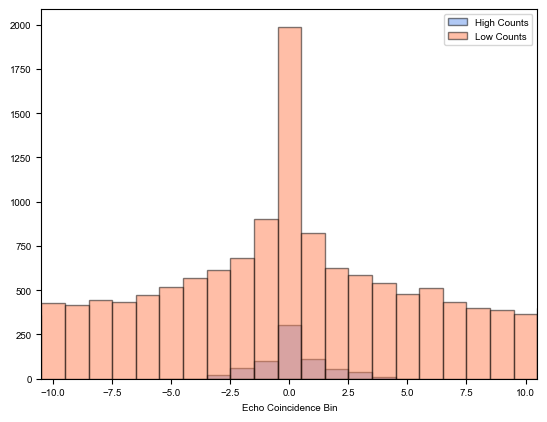

In [24]:
labels = ['High Counts', 'Low Counts']
colors = ['cornflowerblue', 'coral']
idx_to_plot = 0
for data, label, color in zip([all_high_sums[idx_to_plot], all_low_sums[idx_to_plot]], labels, colors):
    x_data = np.arange(len(data)) - (len(data) - 1) / 2
    plt.bar(x_data, data,
            width=1, color=color, edgecolor='k', alpha=0.5,
            label=label)

plt.xlim(-10.5, 10.5)
plt.legend()
plt.xlabel('Echo Coincidence Bin')

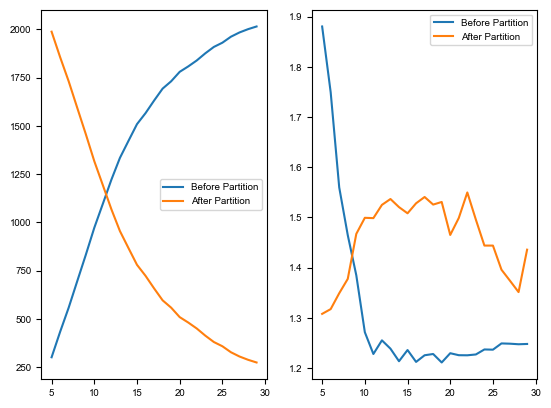

In [25]:
fig, axs = plt.subplots(1, 2)

axs[0].plot(partitions, all_high_counts,
            label='Before Partition')
axs[0].plot(partitions, all_low_counts,
            label='After Partition')
axs[0].legend()

axs[1].plot(partitions, all_high_car,
            label='Before Partition')
axs[1].plot(partitions, all_low_car,
            label='After Partition')
axs[1].legend()

## Final Plotting

In [29]:
figsize = (4, 3)

# colors
color_source = '#7570b3'
color_source_2 = 'darkgray'
color_memory = '#d95f02'
color_memory_2 = 'darkgray'

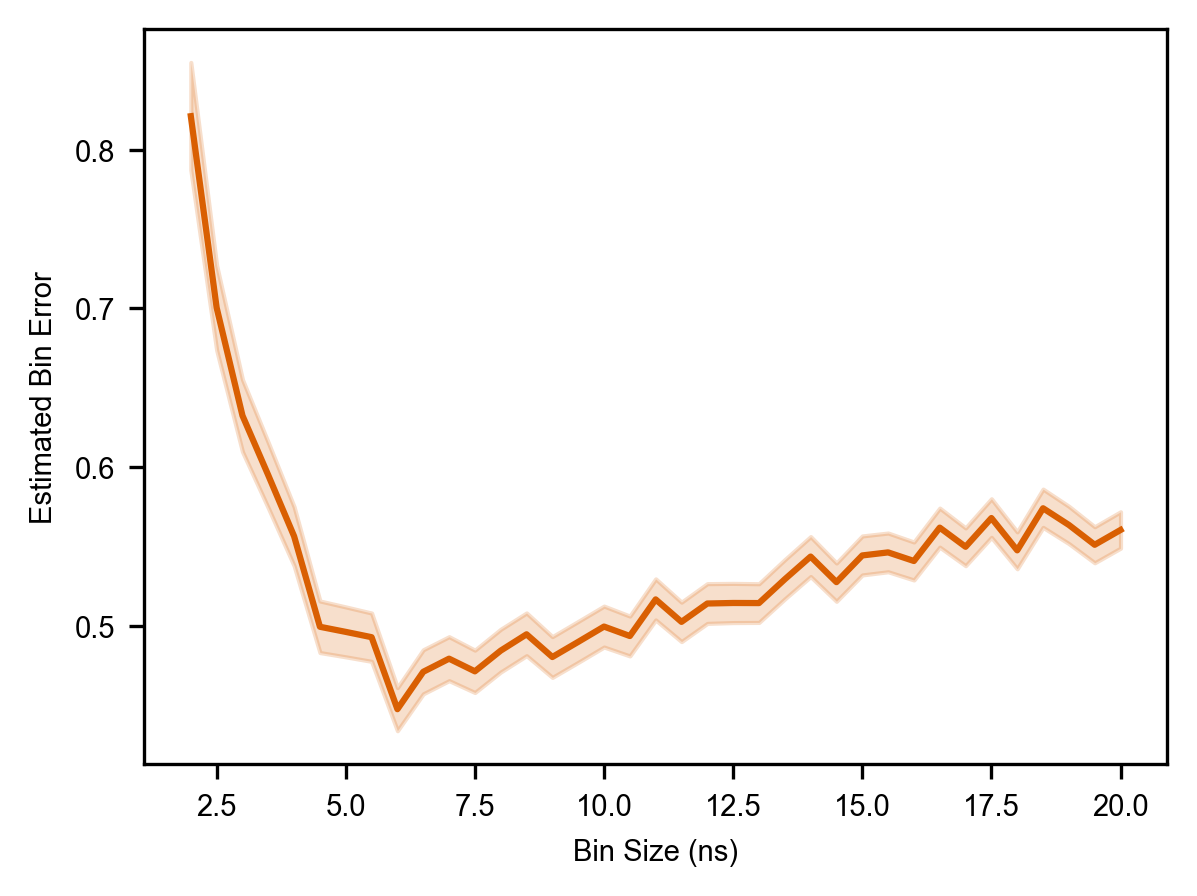

In [43]:
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)


# NOTE: contrast is 1 + CAR value, so subtract 1 to plot CAR
# axs[0].errorbar(np.array(rebin_factors) * bin_size, contrast_vals-1, yerr=contrast_err,
#                 marker='o', markersize=2, capsize=2, color=color_memory)
ax.plot(np.array(rebin_factors) * bin_size, contrast_error,
        color=color_memory, label='Contrast')
ax.fill_between(np.array(rebin_factors) * bin_size,
                y1=contrast_error-error_yerr,
                y2=contrast_error+error_yerr,
                color=color_memory, alpha=0.2)
ax.set_xlabel('Bin Size (ns)')
ax.set_ylabel('Estimated Bin Error')

# axs[1].plot(partition_time, all_high_car, color=color_memory,
#             label='Before Partition')
# axs[1].fill_between(partition_time,
#                     y1=all_high_car-all_high_car_err,
#                     y2=all_high_car+all_high_car_err,
#                     color=color_memory, alpha=0.2)
# axs[1].plot(partition_time, all_low_car, color=color_source,
#             label='After Partition')
# axs[1].fill_between(partition_time,
#                     y1=all_low_car-all_low_car_err,
#                     y2=all_low_car+all_low_car_err,
#                     color=color_source, alpha=0.2)
# axs[1].set_xlabel('Echo Partition Time (ns)')
# axs[1].set_ylabel('CAR')
# axs[1].legend(frameon=False)
#
# partition_time = partitions * bin_size * factor
# axs[2].plot(partition_time, all_high_counts, color=color_memory,
#             label='Before Partition')
# axs[2].plot(partition_time, all_low_counts, color=color_source,
#             label='After Partition')
# axs[2].set_xlabel('Echo Partition Time (ns)')
# axs[2].set_ylabel('Total Coincidences')
# axs[2].legend(frameon=False)

fig.tight_layout()

In [44]:
fig.savefig('supp_qudit_analysis.pdf')